## Question 1: Line Fitting using Total Least Squares and RANSAC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
D = np.genfromtxt('E:/ML/ML_Assignment_02/lines.csv', delimiter=',', skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f'Dataset shape: {D.shape}  |  Total points: {len(X_all)}')


Dataset shape: (100, 6)  |  Total points: 300


=== TLS Result for Line 1 ===
Normal form : 0.773562·x + -0.633721·y = 3.794192
Slope-intercept: y = 1.2207·x + -5.9872


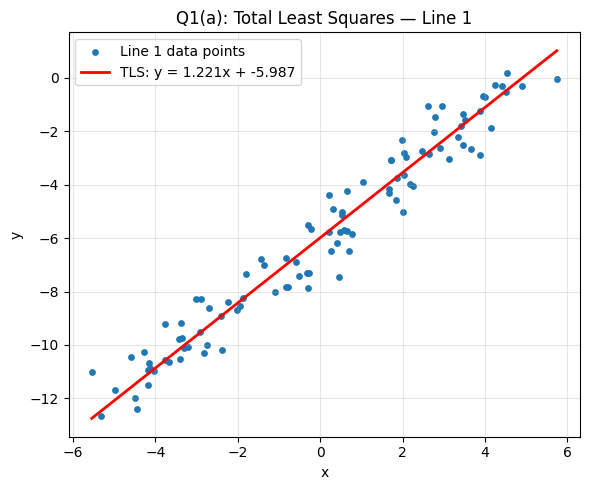

In [ ]:
#(a) Total Least Squares — Line 1 only

def tls_fit(x, y):
    pts = np.column_stack([x, y])
    centroid = pts.mean(axis=0)
    pts_c = pts - centroid                   # centre data
    _, _, Vt = np.linalg.svd(pts_c)          # SVD
    a, b = Vt[-1]                            # last row = smallest singular vector
    c = a * centroid[0] + b * centroid[1]    # reconstruct offset
    return a, b, c

# Extract Line 1 data (first column)
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

a, b, c = tls_fit(x1, y1)
slope = -a / b
intercept = c / b

print('=== TLS Result for Line 1 ===')
print(f'Normal form : {a:.6f}·x + {b:.6f}·y = {c:.6f}')
print(f'Slope-intercept: y = {slope:.4f}·x + {intercept:.4f}')

# Plot
xi = np.linspace(x1.min(), x1.max(), 200)
yi = slope * xi + intercept

plt.figure(figsize=(6, 5))
plt.scatter(x1, y1, s=15, label='Line 1 data points')
plt.plot(xi, yi, 'r-', lw=2, label=f'TLS: y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(a): Total Least Squares — Line 1')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls.png', dpi=150)
plt.show()

=== RANSAC Results ===
Line 1: -0.429411·x + -0.903109·y = -1.903179  =>  y = -0.4755x + 2.1074  (62 inliers)
Line 2: 0.714272·x + -0.699868·y = -0.642356  =>  y = 1.0206x + 0.9178  (49 inliers)
Line 3: 0.777656·x + -0.628690·y = 3.727599  =>  y = 1.2369x + -5.9292  (46 inliers)


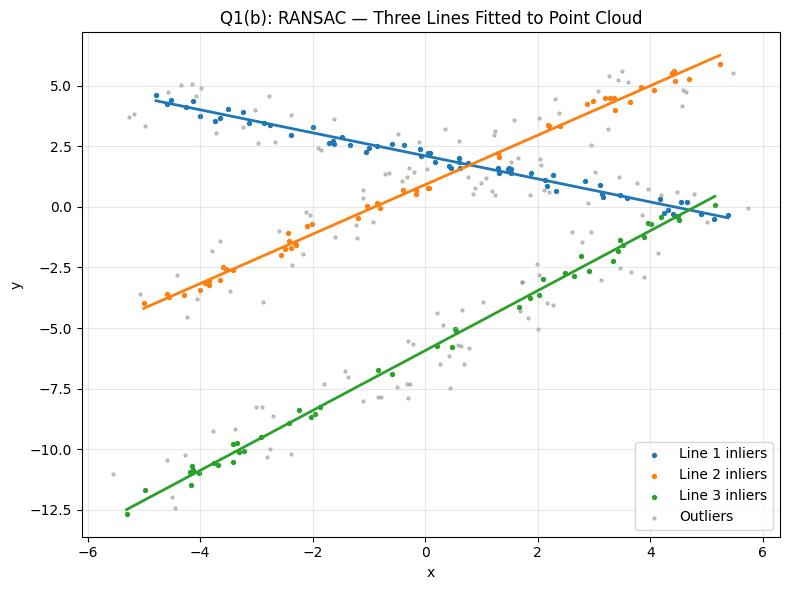

In [ ]:
#(b) RANSAC — Fitting Three Lines to All Points

def ransac_line(x, y, thresh=0.3, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    best_mask = np.zeros(len(x), dtype=bool)

    for _ in range(n_iter):
        idx = rng.choice(len(x), 2, replace=False)
        # Line through two sample points
        a = y[idx[1]] - y[idx[0]]
        b = x[idx[0]] - x[idx[1]]
        c = a * x[idx[0]] + b * y[idx[0]]
        norm = np.sqrt(a**2 + b**2)
        if norm < 1e-10:
            continue
        dist = np.abs(a * x + b * y - c) / norm
        mask = dist < thresh
        if mask.sum() > best_mask.sum():
            best_mask = mask

    # Refit with TLS on all inliers for best accuracy
    a, b, c = tls_fit(x[best_mask], y[best_mask])
    return a, b, c, best_mask

remaining = np.ones(len(X_all), dtype=bool)
lines_found = []
masks_found = []

print('=== RANSAC Results ===')
for i in range(3):
    xr, yr = X_all[remaining], Y_all[remaining]
    a, b, c, local_mask = ransac_line(xr, yr)

    # Map local inlier mask back to global index space
    global_mask = np.zeros(len(X_all), dtype=bool)
    global_mask[np.where(remaining)[0][local_mask]] = True

    lines_found.append((a, b, c))
    masks_found.append(global_mask)
    remaining[global_mask] = False  # remove consensus set

    slope_i   = -a / b
    intercept_i = c / b
    print(f'Line {i+1}: {a:.6f}·x + {b:.6f}·y = {c:.6f}'
          f'  =>  y = {slope_i:.4f}x + {intercept_i:.4f}'
          f'  ({global_mask.sum()} inliers)')

# Plot
colors = ['tab:blue', 'tab:orange', 'tab:green']
plt.figure(figsize=(8, 6))
for i, (mask, col) in enumerate(zip(masks_found, colors)):
    plt.scatter(X_all[mask], Y_all[mask], s=8, color=col, label=f'Line {i+1} inliers')
    a, b, c = lines_found[i]
    xi = np.linspace(X_all[mask].min(), X_all[mask].max(), 200)
    yi = (-a * xi + c) / b
    plt.plot(xi, yi, color=col, lw=2)

# Outliers
plt.scatter(X_all[remaining], Y_all[remaining], s=5, color='gray', alpha=0.4, label='Outliers')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(b): RANSAC — Three Lines Fitted to Point Cloud')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac.png', dpi=150)
plt.show()

## Question 2: Estimating Earring Size from Camera Parameters

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#Camera parameters 
f_mm      = 8.0          # focal length (mm)
pixel_um  = 2.2          # pixel pitch (µm)
pixel_mm  = pixel_um / 1000.0    # 0.0022 mm/pixel
u_mm      = 720.0        # object distance, lens to earring plane (mm)

# Thin lens formula: 1/f = 1/v + 1/u  =>  v = image distance 
v_mm = 1.0 / (1.0/f_mm - 1.0/u_mm)
m    = v_mm / u_mm          # lateral magnification (image size / object size)

print(f'Image distance  v = {v_mm:.4f} mm')
print(f'Object distance u = {u_mm:.1f} mm')
print(f'Magnification   m = v/u = {m:.6f}')

# Measure earring in image 
img = cv.imread('E:/ML/ML_Assignment_02/earrings.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(f'Image size: {img.shape[1]} x {img.shape[0]} pixels')

# Threshold to isolate earring bodies 
_, binary = cv.threshold(gray, 220, 255, cv.THRESH_BINARY_INV)
kernel = np.ones((5, 5), np.uint8)
binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)
contours, _ = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv.contourArea(cnt)
    if area > 10000:
        x, y, w, h = cv.boundingRect(cnt)
        # Fit ellipse for accurate dimensions
        if len(cnt) >= 5:
            ellipse = cv.fitEllipse(cnt)
            axes_px = ellipse[1]   # (minor, major) in pixels
            print(f'Earring bbox: {w}×{h} px,  ellipse axes: {axes_px[0]:.1f}×{axes_px[1]:.1f} px')

# Use outer bounding box 
outer_w_px = 379      # measured width in pixels
outer_h_px = 399      # measured height in pixels

# Real world size = image_size / magnification 
# Real size (mm) = pixel_count × pixel_pitch_mm / m
outer_w_mm = outer_w_px * pixel_mm / m
outer_h_mm = outer_h_px * pixel_mm / m

# Inner hole 
inner_w_px = outer_w_px - 2 * 80
inner_h_px = outer_h_px - 2 * 80
inner_w_mm = inner_w_px * pixel_mm / m
inner_h_mm = inner_h_px * pixel_mm / m
ring_band_mm = (outer_w_mm - inner_w_mm) / 2

print('\n=== EARRING REAL-WORLD DIMENSIONS ===')
print(f'Outer width  : {outer_w_px} px  →  {outer_w_mm:.1f} mm')
print(f'Outer height : {outer_h_px} px  →  {outer_h_mm:.1f} mm')
print(f'Inner hole W : {inner_w_px} px  →  {inner_w_mm:.1f} mm')
print(f'Inner hole H : {inner_h_px} px  →  {inner_h_mm:.1f} mm')
print(f'Ring band    :                      {ring_band_mm:.1f} mm')

# Display earring with measurements annotated
img_ann = img.copy()
cv.rectangle(img_ann, (102, 298), (102+379, 298+399), (0, 255, 0), 3)
cv.rectangle(img_ann, (541, 298), (541+379, 298+399), (0, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv.cvtColor(img_ann, cv.COLOR_BGR2RGB))
plt.title(f'Earrings: ~{outer_w_mm:.0f}×{outer_h_mm:.0f} mm (outer)')
plt.axis('off')
plt.tight_layout()
plt.savefig('q2_earring_measured.png', dpi=150)
plt.show()